
Processing U11.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_12', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


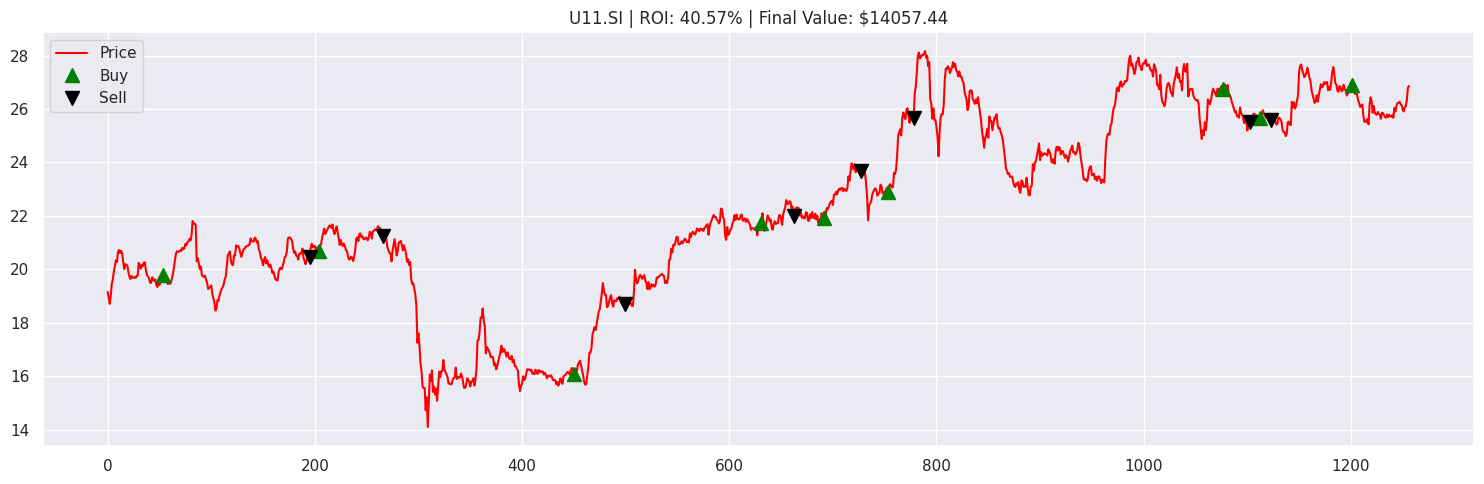


Processing C38U.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_13', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


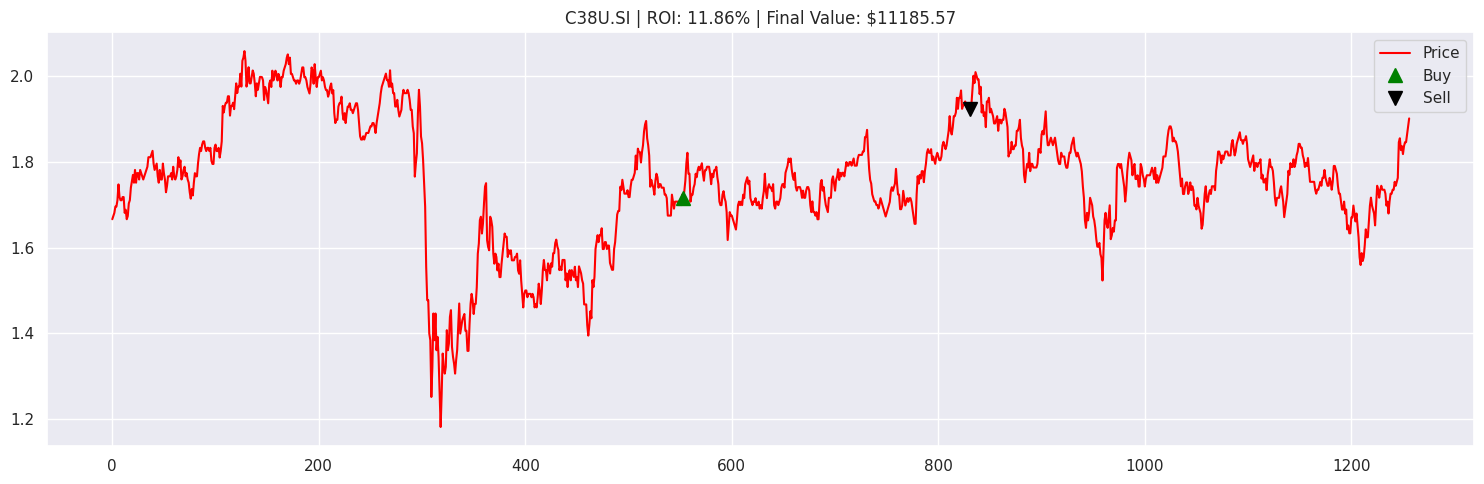


Processing Q0F.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_14', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


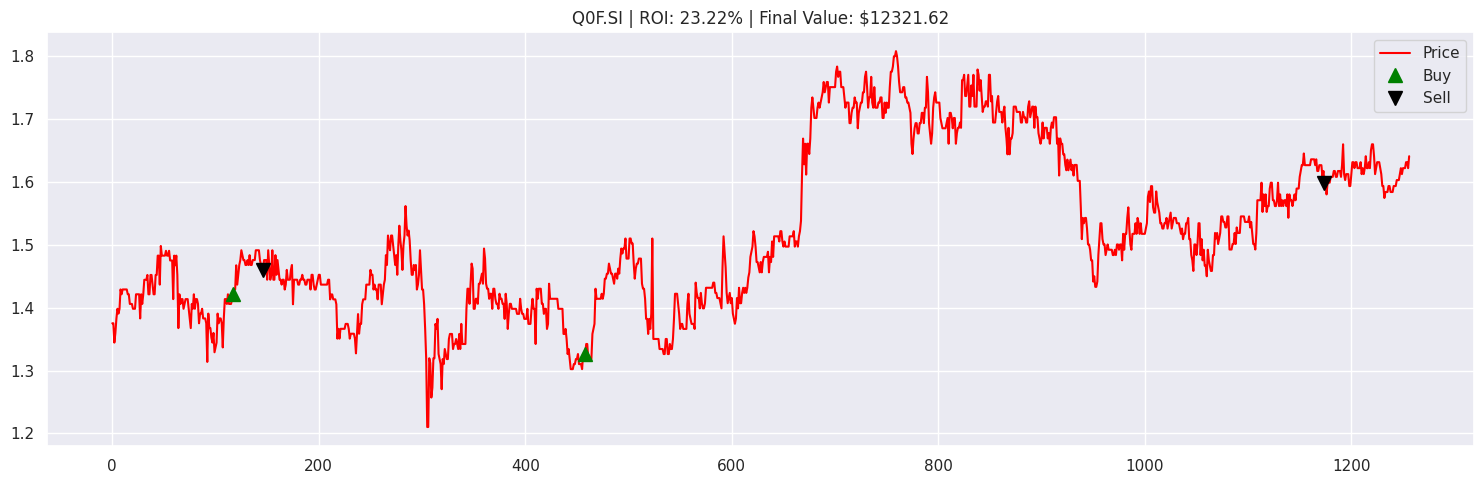


Processing S68.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_15', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


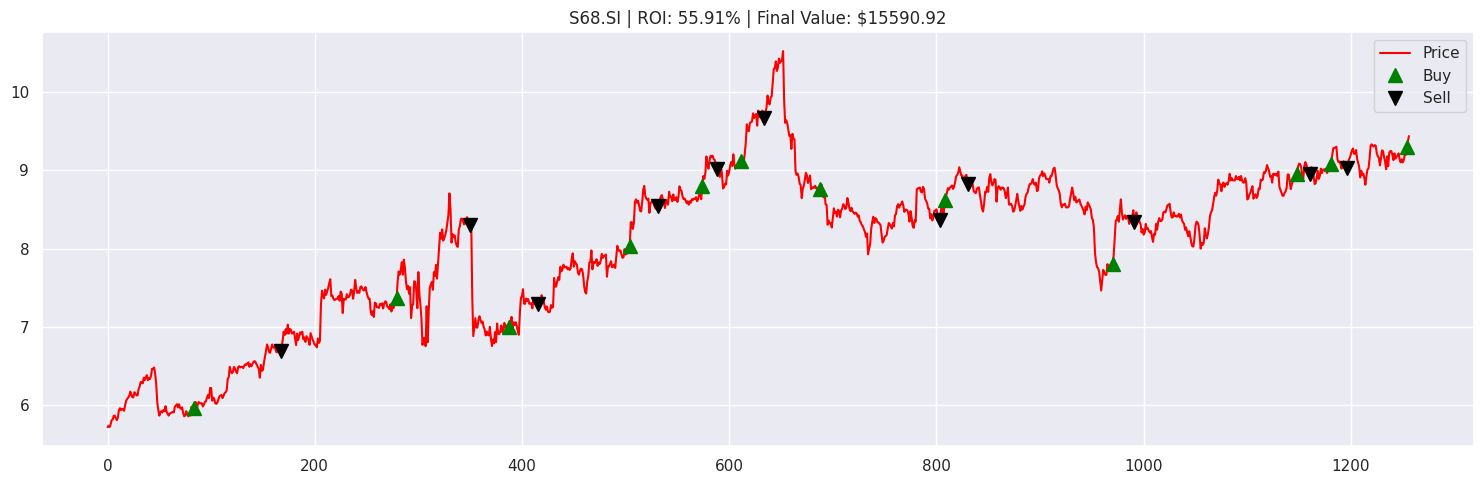


Processing S63.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_16', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


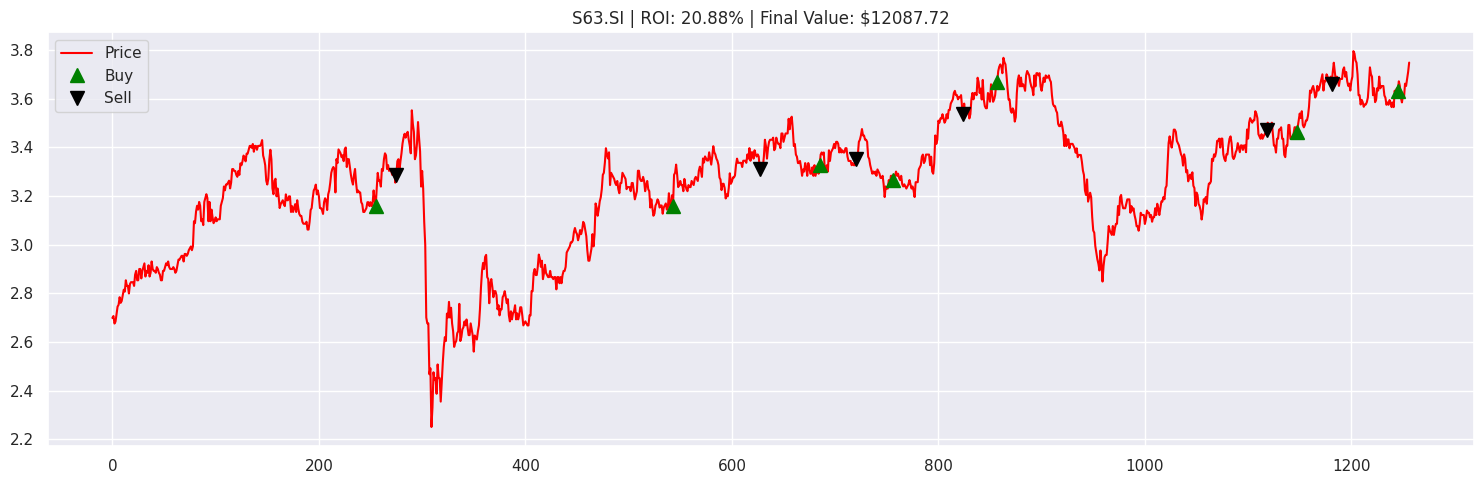


Processing AJBU.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'ppo_policy_17', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


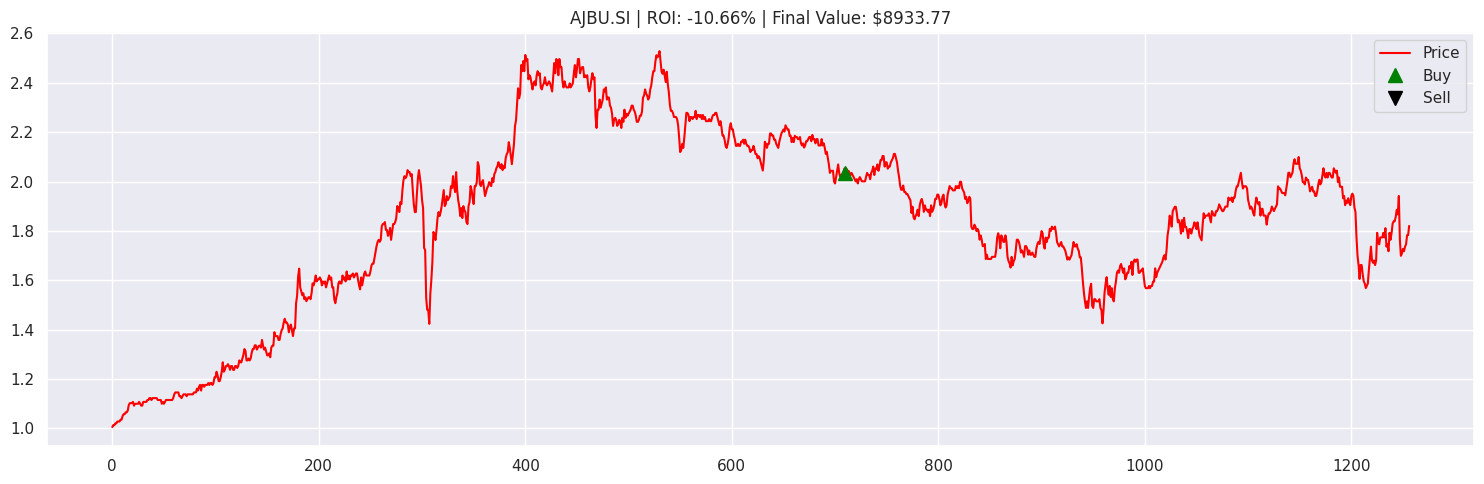


Portfolio Summary:
               ROI   Final Value
U11.SI   40.574406  14057.440587
C38U.SI  11.855688  11185.568812
Q0F.SI   23.216243  12321.624348
S68.SI   55.909205  15590.920489
S63.SI   20.877200  12087.719967
AJBU.SI -10.662293   8933.770734


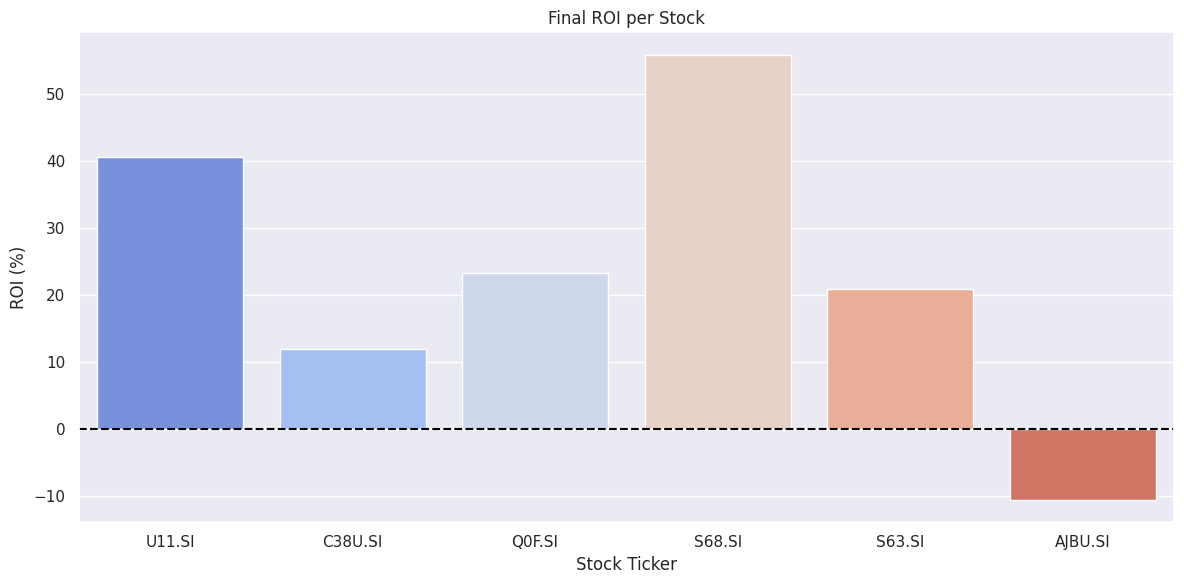

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random

sns.set()

# Parameters
initial_money = 10000
window_size = 30
commission = 0.00125
alpha_threshold = 0.004
beta_threshold = -0.004
risk_rsi_low = 30
risk_rsi_high = 70
min_trade_profit = 0.002
volatility_buffer = 0.008
trend_confirm_window = 10

# Indicator Functions
def RMA(series, period):
    rma = [series[0]]
    alpha = 1 / period
    for price in series[1:]:
        rma.append((1 - alpha) * rma[-1] + alpha * price)
    return np.array(rma)

def apply_second_order_rma(prices):
    return RMA(RMA(prices, 25), 9)

def compute_macd(prices, short=12, long=26, signal=9):
    ema_short = pd.Series(prices).ewm(span=short).mean()
    ema_long = pd.Series(prices).ewm(span=long).mean()
    macd_line = ema_short - ema_long
    signal_line = macd_line.ewm(span=signal).mean()
    return macd_line.values, signal_line.values

def compute_rsi(prices, period=14):
    delta = np.diff(prices)
    up = np.where(delta > 0, delta, 0)
    down = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(up).rolling(window=period).mean()
    avg_loss = pd.Series(down).rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return np.concatenate([np.full(period, np.nan), rsi[period:]])

# PPO Agent
class PPOPolicy(tf.keras.Model):
    def __init__(self, input_dim, output_dim):
        super(PPOPolicy, self).__init__()
        self.lstm = tf.keras.layers.LSTM(128, return_sequences=True, return_state=True)
        self.actor = tf.keras.layers.Dense(output_dim, activation='softmax')
        self.critic = tf.keras.layers.Dense(1)

    def call(self, inputs, states):
        x, h, c = self.lstm(inputs, initial_state=states)
        logits = self.actor(x[:, -1])
        value = self.critic(x[:, -1])
        return logits, value, (h, c)

class PPOAgent:
    def __init__(self, input_dim, action_dim):
        self.policy = PPOPolicy(input_dim, action_dim)
        self.policy.build(input_shape=(None, None, input_dim))
        self.optimizer = tf.keras.optimizers.Adam(0.0003)
        self.gamma = 0.99
        self.clip_ratio = 0.2
        self.state_dim = input_dim
        self.action_dim = action_dim

    def get_state(self, t, trend):
        d = t - window_size + 1
        block = trend[d:t+1] if d >= 0 else -d * [trend[0]] + trend[0:t+1]
        delta = [block[i+1] - block[i] for i in range(window_size - 1)]
        rma2 = apply_second_order_rma(block)[-1]
        macd_line, signal_line = compute_macd(block)
        rsi = compute_rsi(block)
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50
        return np.array(delta + [rma2, macd_diff, rsi_val])

    def get_action(self, state):
        state = state.reshape(1, 1, -1).astype(np.float32)
        hidden = [tf.zeros((1, 128)), tf.zeros((1, 128))]
        probs, _, _ = self.policy(state, hidden)
        action = np.random.choice(self.action_dim, p=probs.numpy()[0])
        return action

# Execution Loop
portfolio_results = {}
tickers = {
    "U11.SI": "UOB Bank",
    "C38U.SI": "CapitaLand Integrated Commercial Trust",
    "Q0F.SI": "IHH Healthcare",
    "S68.SI": "SGX",
    "S63.SI": "ST Engineering",
    "AJBU.SI": "Keppel DC REIT"
}

for ticker in tickers:
    print(f"\nProcessing {ticker}...")
    # df = pd.read_csv(f"/home/priya/Desktop/fyp/Agents/data_store/{ticker}.csv")
    # df = df.dropna(subset=["Close"])  # Drop any NaNs in Close
    # close = df['Close'].values.tolist()
    df = pd.read_csv(f"/home/priya/Desktop/Multi-agent-fuzzy-neural-stock-prediction/Src/data/{ticker}/ensemble_outputs/{ticker}_ensemble_output_results.csv")
    close = df['yref_Tm0_close'].values.tolist()
    if len(close) < window_size + 20:
        print(f"Skipping {ticker} due to insufficient data.")
        continue

    agent = PPOAgent(window_size - 1 + 3, 3)
    portfolio = initial_money
    shares_held = 0
    states_buy, states_sell = [], []

    for t in range(window_size, len(close) - 1):
        state = agent.get_state(t, close)
        action = agent.get_action(state)

        macd_line, signal_line = compute_macd(close[max(0, t-50):t+1])
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi = compute_rsi(close[max(0, t-50):t+1])
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50

        # current_price = close[t]
        # expected_profit = close[t+1] * (1 - commission) - current_price * (1 + commission)
        # Calculate recent trend confirmation and volatility
        recent_prices = close[max(0, t-trend_confirm_window+1):t+1]
        if len(recent_prices) < trend_confirm_window:
            continue  # not enough data for trend confirmation

        trend_direction = np.sign(recent_prices[-1] - recent_prices[0])
        recent_volatility = np.std(recent_prices) / np.mean(recent_prices)

        trade_action = 0
        current_price = close[t]
        next_price = close[t+1]
        expected_profit = next_price * (1 - commission) - current_price * (1 + commission)
        expected_roi = expected_profit / (current_price * (1 + commission))

        # Skip if expected ROI is negative
        if expected_roi <= 0:
            trade_action = 0
        else:
            # Buy Condition
            if (macd_diff > alpha_threshold and rsi_val < risk_rsi_high
                and expected_profit > min_trade_profit * current_price
                and trend_direction > 0
                and recent_volatility < volatility_buffer
                and portfolio >= current_price * (1 + commission)):
                trade_action = 1

            # Sell Condition (if already holding and sell is beneficial)
            elif (macd_diff < beta_threshold and rsi_val > risk_rsi_low
                and shares_held > 0
                and trend_direction < 0
                and recent_volatility < volatility_buffer):

                sell_price = current_price * (1 - commission)
                avg_buy_price = (initial_money - portfolio) / shares_held if shares_held else 0
                if sell_price > avg_buy_price:
                    trade_action = 2
                else:
                    trade_action = 0  # Hold if selling locks in a loss


        # trade_action = 0
        # if action == 1 and macd_diff > alpha_threshold and rsi_val < risk_rsi_high and expected_profit > min_trade_profit * current_price:
        #     trade_action = 1
        # elif action == 2 and macd_diff < beta_threshold and rsi_val > risk_rsi_low and shares_held > 0:
        #     trade_action = 2

        if trade_action == 1 and portfolio >= current_price * (1 + commission):
            shares_to_buy = portfolio // (current_price * (1 + commission))
            portfolio -= shares_to_buy * current_price * (1 + commission)
            shares_held += shares_to_buy
            states_buy.append(t)
        elif trade_action == 2 and shares_held > 0:
            portfolio += shares_held * current_price * (1 - commission)
            shares_held = 0
            states_sell.append(t)

    portfolio_value = portfolio + shares_held * close[-1]
    roi = (portfolio_value - initial_money) / initial_money * 100
    portfolio_results[ticker] = {"ROI": roi, "Final Value": portfolio_value}

    plt.figure(figsize=(15, 5))
    plt.plot(close, label='Price', color='red')
    plt.plot(close, '^', markersize=10, color='green', label='Buy', markevery=states_buy)
    plt.plot(close, 'v', markersize=10, color='black', label='Sell', markevery=states_sell)
    plt.title(f"{ticker} | ROI: {roi:.2f}% | Final Value: ${portfolio_value:.2f}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(portfolio_results).T
print("\nPortfolio Summary:")
print(results_df)
results_df.to_csv('results_ppo.csv')

plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df["ROI"], hue=results_df.index, dodge=False, palette="coolwarm", legend=False)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Final ROI per Stock")
plt.ylabel("ROI (%)")
plt.xlabel("Stock Ticker")
plt.tight_layout()
plt.show()
